In [2]:
import pandas as pd
from transformers import pipeline

c:\Users\71486\Test_MT\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('more_data.csv')
df

,Unnamed: 0,Comment,Rating
0,0,Another Midrange killer Smartphone by Xiaomi A...,4.0
1,1,vry small size mobile All ok but vry small siz...,3.0
2,2,Full display not working in all application. Q...,3.0
3,3,Value for Money Redmi has always have been the...,5.0
4,4,Not worth for the money worst product from MI....,2.0
...,...,...,...
613,683,"This Mobile Really Nice\nCamera, Battery Excel...",5.0
614,684,Display size is Vary good.\nideal display for ...,5.0
615,685,Hands on to the first ever BLACK REDMI 6. slee...,5.0
616,686,very good quality,5.0


In [4]:
df.duplicated().value_counts()

False    618
Name: count, dtype: int64

In [5]:
import tiktoken

In [7]:
model = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

# STEP 6: Prediksi sentimen dari kolom 'gabungan'
def map_label(label):
    rating = int(label[0])
    if rating >= 4:
        return 'positif'
    elif rating == 3:
        return 'netral'
    else:
        return 'negatif'

results = model(df['Comment'].astype(str).tolist(), truncation=True)

df['label_help'] = [map_label(r['label']) for r in results]

Device set to use cpu


In [ ]:
df

,Unnamed: 0,Comment,Rating,label_help
0,0,Another Midrange killer Smartphone by Xiaomi A...,4.0,positif
1,1,vry small size mobile All ok but vry small siz...,3.0,netral
2,2,Full display not working in all application. Q...,3.0,netral
3,3,Value for Money Redmi has always have been the...,5.0,positif
4,4,Not worth for the money worst product from MI....,2.0,negatif
...,...,...,...,...
613,683,"This Mobile Really Nice\nCamera, Battery Excel...",5.0,positif
614,684,Display size is Vary good.\nideal display for ...,5.0,positif
615,685,Hands on to the first ever BLACK REDMI 6. slee...,5.0,positif
616,686,very good quality,5.0,positif


In [ ]:
df.label_help.value_counts()

label_help
positif    348
negatif    221
netral      49
Name: count, dtype: int64

<Axes: title={'center': 'Distribusi Sentimen'}, xlabel='label_help'>

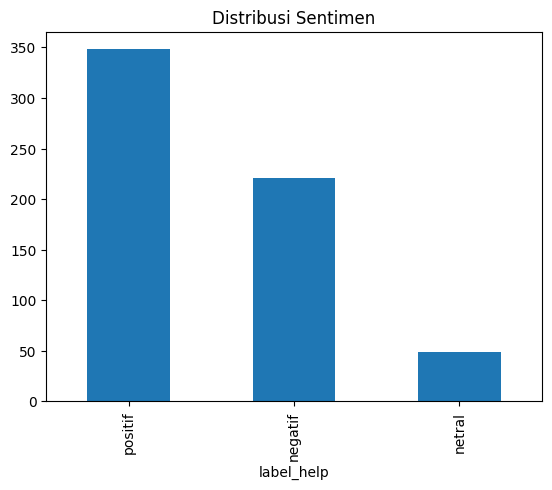

In [40]:
df['label_help'].value_counts().plot(kind='bar', title="Distribusi Sentimen")

## Bikin Model

In [52]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load model & tokenizer
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Fungsi ekstrak embedding dari [CLS] token
def get_bert_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()  # ambil token [CLS]
    return cls_embedding


In [10]:
# Contoh dataframe df['comment_lemmatized'] dan df['label_real']
# Apply ke semua teks (agak lama)
X = np.array([get_bert_embedding(text) for text in df['Comment']])
y = df['label_help']

# Split dan training


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# SVC dengan setting optimal umum
clf = SVC(
    kernel='linear',       # Linear cocok untuk teks
    C=1.0,                 # Regularisasi (1.0 = default, bisa naik-turun sesuai kebutuhan)
    class_weight='balanced',  # Menangani kelas tidak seimbang
    probability=True,      # Aktifkan predict_proba (kalau kamu butuh)
    random_state=42
)

# Training
clf.fit(X_train, y_train)

# Prediksi & Evaluasi
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     negatif       0.85      0.91      0.88        44
      netral       0.50      0.30      0.38        10
     positif       0.90      0.91      0.91        70

    accuracy                           0.86       124
   macro avg       0.75      0.71      0.72       124
weighted avg       0.85      0.86      0.85       124



In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['positif', 'netral', 'negatif'])

print(cm)

[[64  2  4]
 [ 4  3  3]
 [ 3  1 40]]


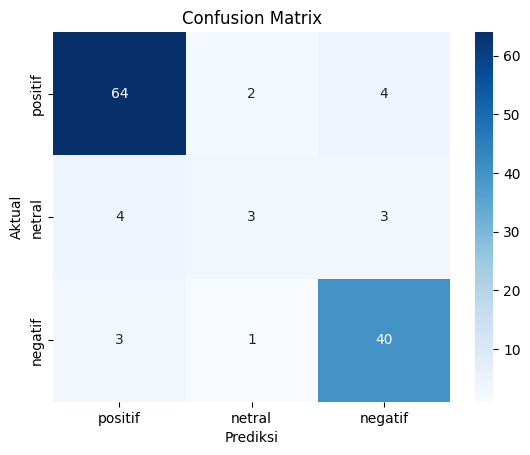

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positif', 'netral', 'negatif'],
            yticklabels=['positif', 'netral', 'negatif'])

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()


In [16]:
def prediksi_manual(teks):
    emb = get_bert_embedding(teks)
    label = clf.predict([emb])[0]
    proba = clf.predict_proba([emb])[0]
    return label, dict(zip(clf.classes_, proba))

# Contoh
teks_uji = "overall the camera is not bad tho"
label, skor = prediksi_manual(teks_uji)
print(f"\nTeks: {teks_uji}\nPrediksi: {label}\nProbabilitas: {skor}")


Teks: overall the camera is not bad tho
Prediksi: netral
Probabilitas: {'negatif': np.float64(0.14145812134736319), 'netral': np.float64(0.5221606744629024), 'positif': np.float64(0.33638120418973466)}


In [17]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# SVC dengan setting optimal umum
clf = SVC(
    kernel='linear',       # Linear cocok untuk teks
    C=1.0,                 # Regularisasi (1.0 = default, bisa naik-turun sesuai kebutuhan)
    class_weight='balanced',  # Menangani kelas tidak seimbang
    probability=True,      # Aktifkan predict_proba (kalau kamu butuh)
    random_state=42
)

# Training
clf.fit(X, y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


## USE A TEST CASE

In [18]:
df_test = pd.read_csv('flipkart_redmi6_reviews_with_rating_test.csv')
df_test

,rating,review
0,3,Good
1,3,Value for money
2,4,Good
3,3,"Budget oriented phone,decent camera battery ba..."
4,1,Worst performance
...,...,...
195,3,Nice phone
196,1,It is the picture quality
197,4,Super
198,5,Very nice 👍 thanks 👍


In [46]:
df_test.drop_duplicates(inplace=True)

In [47]:
model = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

# STEP 6: Prediksi sentimen dari kolom 'gabungan'
def map_label(label):
    rating = int(label[0])
    if rating >= 4:
        return 'positif'
    elif rating == 3:
        return 'netral'
    else:
        return 'negatif'

results = model(df_test['review'].astype(str).tolist(), truncation=True)

df_test['label_help'] = [map_label(r['label']) for r in results]

Device set to use cpu


In [48]:
df_test

,rating,review,label_help,Comment_lemma
0,3,Good,positif,good
1,3,Value for money,positif,value for money
2,4,Good,positif,good
3,3,"Budget oriented phone,decent camera battery ba...",netral,budget oriented phone decent camera battery ba...
4,1,Worst performance,negatif,worst performance
...,...,...,...,...
195,3,Nice phone,positif,nice phone
196,1,It is the picture quality,positif,it is the picture quality
197,4,Super,positif,super
198,5,Very nice 👍 thanks 👍,positif,very nice thanks


In [49]:
df_test.label_help.value_counts()

label_help
positif    103
negatif     23
netral      10
Name: count, dtype: int64

<Axes: title={'center': 'Distribusi Sentimen'}, xlabel='label_help'>

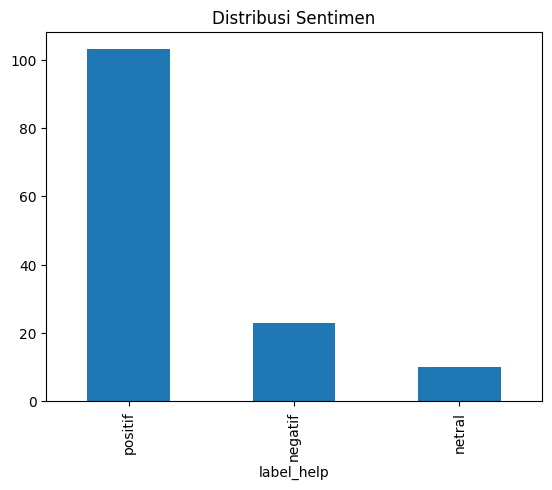

In [50]:
df_test['label_help'].value_counts().plot(kind='bar', title="Distribusi Sentimen")

In [53]:
X_test = np.array([get_bert_embedding(text) for text in df_test['review']])
y_test = df_test['label_help']

In [54]:
# Prediksi & Evaluasi
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     negatif       0.83      0.87      0.85        23
      netral       0.62      0.50      0.56        10
     positif       0.95      0.96      0.96       103

    accuracy                           0.91       136
   macro avg       0.80      0.78      0.79       136
weighted avg       0.91      0.91      0.91       136



In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['positif', 'netral', 'negatif'])

print(cm)

[[161   2   2]
 [  3   7   2]
 [  2   1  20]]


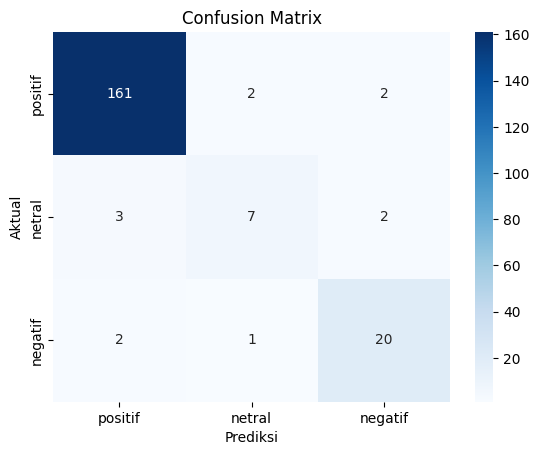

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positif', 'netral', 'negatif'],
            yticklabels=['positif', 'netral', 'negatif'])

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()


## EDA

In [55]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(str(text))
    lemmatized = [lemmatizer.lemmatize(word.lower()) for word in tokens if word.isalpha()]
    return " ".join(lemmatized)

# Simpan hasil lemmatization di kolom baru
df_test['Comment_lemma'] = df_test['review'].apply(lemmatize_text)


In [56]:
from wordcloud import WordCloud, STOPWORDS

# Stopwords bawaan + tambahan dari kamu
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'phone', 'redmi', 'xiaomi', 'mi','good','mobile'  # contoh kata yang sering muncul tapi kurang bermakna
])

In [57]:
text_dict = {
    label: " ".join(df_test[df_test['label_help'] == label]['Comment_lemma'].dropna().astype(str))
    for label in df_test['label_help'].unique()
}


In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random
from collections import Counter

def get_color_func(base_hue=0):
    """
    base_hue: 0 untuk merah, 120 untuk hijau, 240 untuk biru (HSL)
    """
    def color_func(word, font_size, position, orientation, font_path, random_state):
        lightness = 100 - min(font_size, 100)  # makin besar, makin gelap
        return f"hsl({base_hue}, 80%, {lightness}%)"
    return color_func


In [59]:
def buat_wordcloud_frekuensi(label, base_hue):
    text = text_dict.get(label, "")
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=custom_stopwords,
        color_func=get_color_func(base_hue)
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud - {label.upper()}", fontsize=16)
    plt.show()


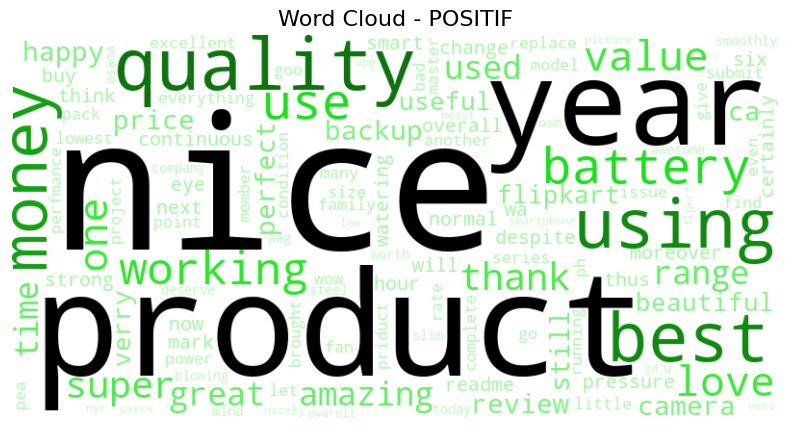

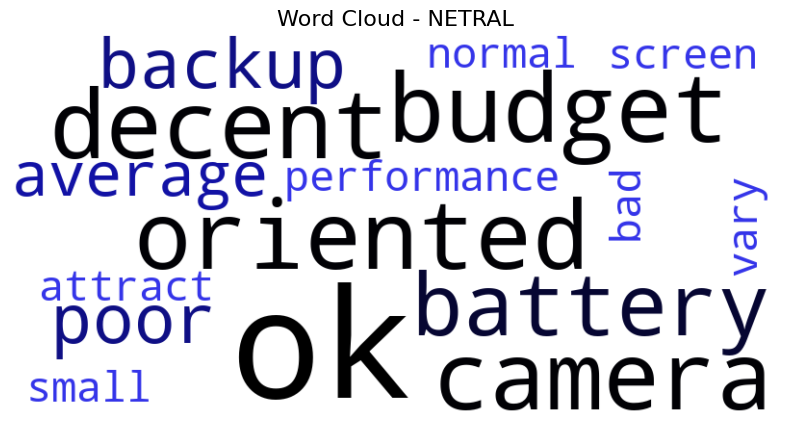

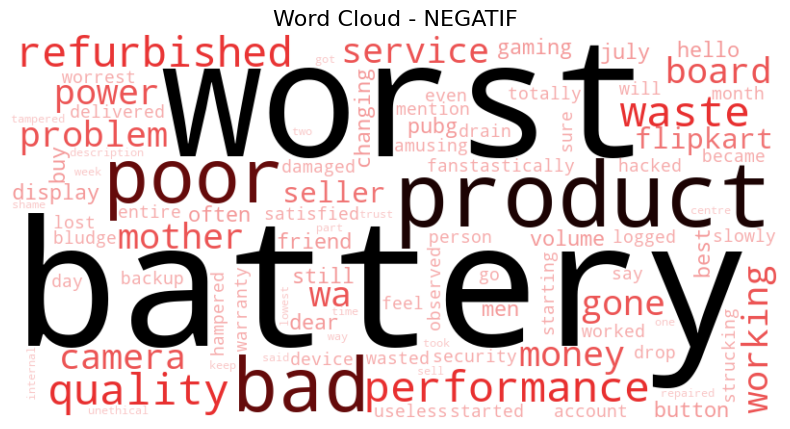

In [60]:
buat_wordcloud_frekuensi('positif', 120)  # green
buat_wordcloud_frekuensi('netral', 240)   # blue
buat_wordcloud_frekuensi('negatif', 0)    # red


In [61]:
from collections import Counter

def hitung_kata_terbanyak(label, top_n=20):
    text = " ".join(df_test[df_test['label_help'] == label]['Comment_lemma'].dropna())
    words = text.lower().split()
    words = [word for word in words if word not in custom_stopwords and word.isalpha()]
    
    counter = Counter(words)
    return counter.most_common(top_n)


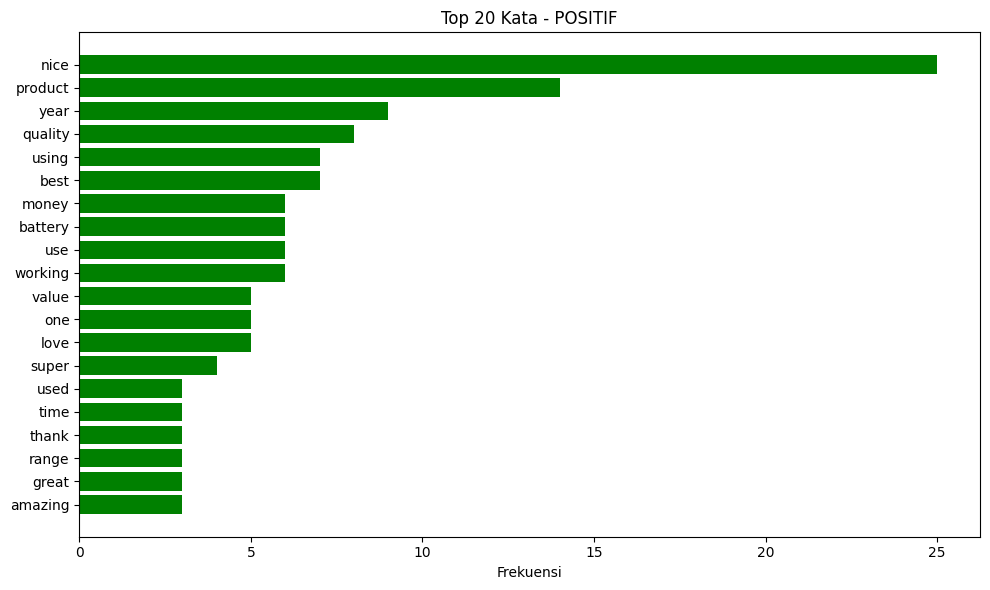

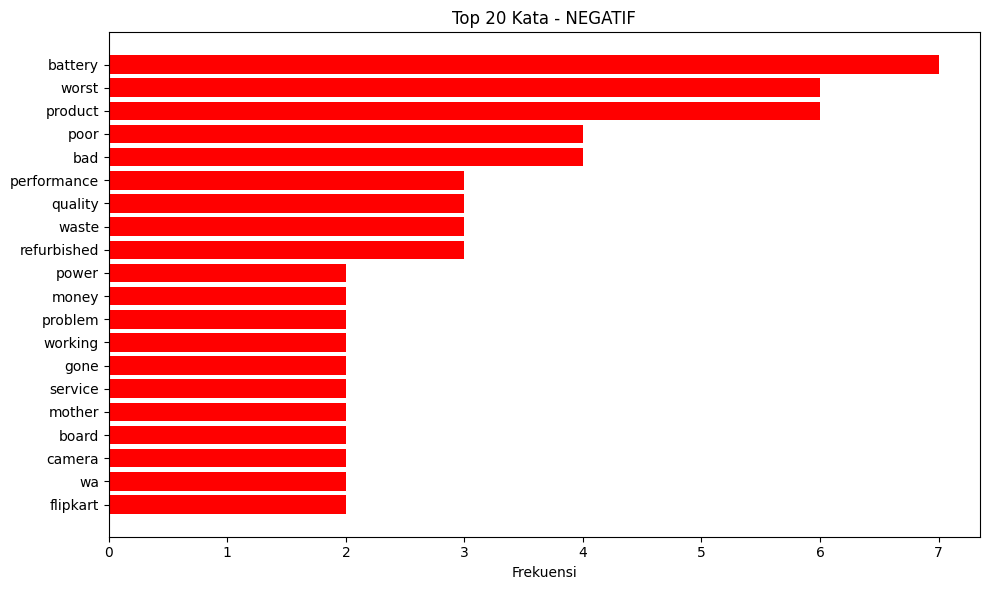

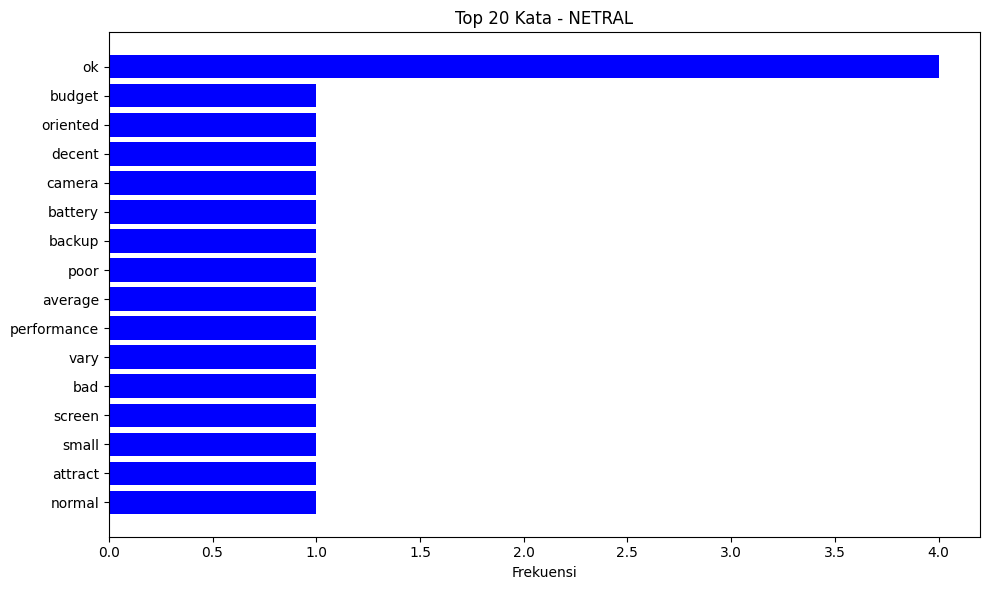

In [62]:
import matplotlib.pyplot as plt

def plot_kata_terbanyak(label, warna='green', top_n=20):
    data = hitung_kata_terbanyak(label, top_n)
    words, freqs = zip(*data)

    plt.figure(figsize=(10, 6))
    plt.barh(words[::-1], freqs[::-1], color=warna)
    plt.xlabel("Frekuensi")
    plt.title(f"Top {top_n} Kata - {label.upper()}")
    plt.tight_layout()
    plt.show()

# Contoh
plot_kata_terbanyak('positif', warna='green')
plot_kata_terbanyak('negatif', warna='red')
plot_kata_terbanyak('netral', warna='blue')
    

In [63]:
import matplotlib.pyplot as plt
import numpy as np

def plot_kata_terbanyak_semua_labels(top_n=15):
    labels = ['positif', 'netral', 'negatif']
    colors = {'positif': 'green', 'netral': 'blue', 'negatif': 'red'}

    # Ambil semua kata teratas dari tiap label
    data_per_label = {label: dict(hitung_kata_terbanyak(label, top_n)) for label in labels}

    # Gabungkan semua kata unik
    all_words = set()
    for d in data_per_label.values():
        all_words.update(d.keys())
    all_words = sorted(all_words)

    # Buat data frekuensi untuk semua label
    freqs = {label: [data_per_label[label].get(word, 0) for word in all_words] for label in labels}

    # Plot
    x = np.arange(len(all_words))  # posisi kata
    width = 0.25  # lebar bar

    plt.figure(figsize=(14, 7))
    for i, label in enumerate(labels):
        plt.bar(x + i * width, freqs[label], width, label=label, color=colors[label])

    plt.xticks(x + width, all_words, rotation=45, ha='right')
    plt.ylabel('Frekuensi')
    plt.title(f"Top Kata Terbanyak per Label (Top {top_n})")
    plt.legend()
    plt.tight_layout()
    plt.show()


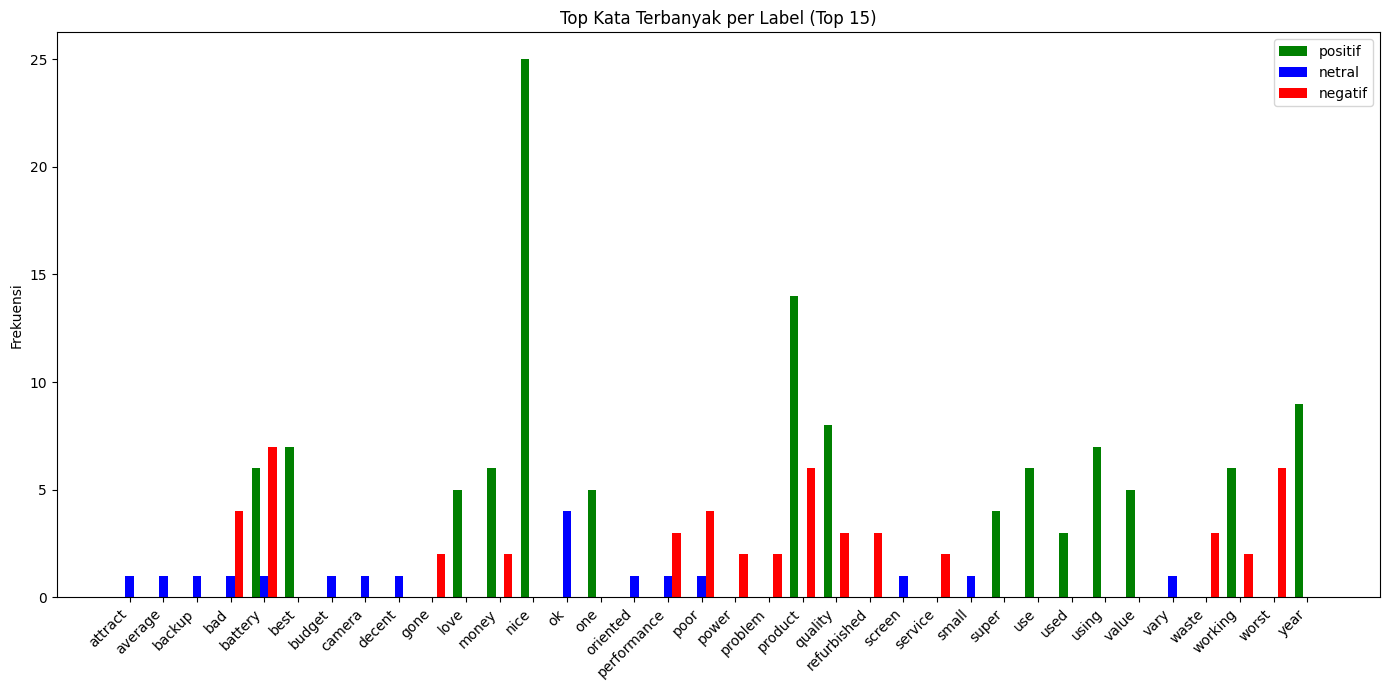

In [64]:
plot_kata_terbanyak_semua_labels(top_n=15)


## Interpretasi